# Formula 1 Driver DNF Prediction Model Exploration & Tuning

This notebook builds, evaluates, tunes, and visualizes predictive models for Formula 1 Driver DNF (Did Not Finish) events using historical Kaggle data (1950–2020).

In [9]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
import optuna
import joblib

# Robust project root finder
cwd = Path.cwd()
project_root = None
for parent in [cwd] + list(cwd.parents):
    if (parent / "model" / "model_pipeline.py").exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    print(f"Project root added to sys.path: {project_root}")
else:
    print("WARNING: Could not find project root automatically.")

from model.model_pipeline import build_dataset

Project root added to sys.path: c:\Users\ericg\ds_school\dsc148\dsc148-f1-project


## 1. Load Dataset

We load the F1 dataset and partition it into train (seasons 1950–2017) and test (seasons 2018–2020) to prevent temporal data leakage.

In [10]:
data_dir = project_root / "data" if project_root else Path("../data")
data = build_dataset(test_year_start=2018, data_dir=data_dir)
print(f"X_train shape: {data.X_train.shape}")
print(f"X_test shape: {data.X_test.shape}")
print(f"Features: {data.feature_cols}")

X_train shape: (22011, 11)
X_test shape: (2972, 11)
Features: ['grid', 'year', 'round', 'driver_age', 'driver_dnf_rate_last5', 'driver_dnf_rate_last10', 'constructor_dnf_rate_last5', 'constructor_dnf_rate_last10', 'circuitId', 'constructorId', 'driverId']


## 2. Preprocess Continuous & Categorical Features

In [11]:
# Impute continuous features
X_train = data.X_train.copy()
X_test = data.X_test.copy()
num_cols = [c for c in data.feature_cols if c not in data.categorical_cols]

for col in num_cols:
    mean_val = X_train[col].mean()
    X_train[col] = X_train[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

y_train = data.y_train.copy()
y_test = data.y_test.copy()
print("Preprocessed features. Missing values filled.")

Preprocessed features. Missing values filled.


## 3. Train Baseline & Advanced Models

We define helper pipelines and dictionaries to train all models and store their predictions for metrics and charting.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve

models_eval = {}
models_probs = {}
models_preds = {}

# 1. Logistic Regression (L2 regularization)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), data.categorical_cols)
    ])
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42, class_weight='balanced'))
])
lr_pipeline.fit(X_train, y_train)
models_preds["Logistic Regression"] = lr_pipeline.predict(X_test)
models_probs["Logistic Regression"] = lr_pipeline.predict_proba(X_test)[:, 1]

# 2. Naive Bayes
nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', GaussianNB())
])
nb_pipeline.fit(X_train, y_train)
models_preds["Naive Bayes"] = nb_pipeline.predict(X_test)
models_probs["Naive Bayes"] = nb_pipeline.predict_proba(X_test)[:, 1]

# 3. Random Forest
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), data.categorical_cols)
    ])
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
models_preds["Random Forest"] = rf_pipeline.predict(X_test)
models_probs["Random Forest"] = rf_pipeline.predict_proba(X_test)[:, 1]

# 4. XGBoost
neg_tr = (y_train == 0).sum()
pos_tr = (y_train == 1).sum()
spw = neg_tr / pos_tr if pos_tr > 0 else 1.0
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.05, scale_pos_weight=spw, random_state=42, n_jobs=-1, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
models_preds["XGBoost"] = xgb_pipeline.predict(X_test)
models_probs["XGBoost"] = xgb_pipeline.predict_proba(X_test)[:, 1]

print("Baseline and initial advanced models trained.")

c:\Users\ericg\ds_school\dsc148\dsc148-f1-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Baseline and initial advanced models trained.


## 4. Hyperparameter Tuning with Optuna (LightGBM)

We use a temporal train/validation split to optimize LightGBM without leaking future seasons.

In [13]:
train_mask = X_train['year'] < 2016
val_mask = X_train['year'] >= 2016

X_tr, y_tr = X_train[train_mask], y_train[train_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]

neg_sub = (y_tr == 0).sum()
pos_sub = (y_tr == 1).sum()
sub_spw = neg_sub / pos_sub if pos_sub > 0 else 1.0

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5 * sub_spw, 2.0 * sub_spw),
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr)
    val_preds = model.predict(X_val)
    return f1_score(y_val, val_preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)
best_params = study.best_params
print("Tuning finished. Best params:", best_params)

[I 2026-05-26 07:43:07,537] A new study created in memory with name: no-name-51665ce1-01b6-4226-8ac7-29bda2bd9772
[I 2026-05-26 07:43:07,995] Trial 0 finished with value: 0.1825726141078838 and parameters: {'learning_rate': 0.10614921483488443, 'num_leaves': 25, 'max_depth': 9, 'min_child_samples': 41, 'scale_pos_weight': 1.3178447956756698}. Best is trial 0 with value: 0.1825726141078838.
[I 2026-05-26 07:43:08,776] Trial 1 finished with value: 0.02197802197802198 and parameters: {'learning_rate': 0.05227539780340424, 'num_leaves': 82, 'max_depth': 9, 'min_child_samples': 94, 'scale_pos_weight': 0.9522858181952278}. Best is trial 0 with value: 0.1825726141078838.
[I 2026-05-26 07:43:09,362] Trial 2 finished with value: 0.15517241379310345 and parameters: {'learning_rate': 0.12887198894575308, 'num_leaves': 90, 'max_depth': 8, 'min_child_samples': 61, 'scale_pos_weight': 1.037742305175915}. Best is trial 0 with value: 0.1825726141078838.
[I 2026-05-26 07:43:09,527] Trial 3 finished wit

Tuning finished. Best params: {'learning_rate': 0.04195883593122704, 'num_leaves': 124, 'max_depth': 10, 'min_child_samples': 14, 'scale_pos_weight': 2.4309258512518648}


## 5. Evaluate Tuned LightGBM

In [14]:
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'random_state': 42,
    'verbosity': -1,
    'n_jobs': -1
}
params.update(best_params)

lgb_tuned = lgb.LGBMClassifier(**params)
lgb_tuned.fit(X_train, y_train)

models_preds["LightGBM (Tuned)"] = lgb_tuned.predict(X_test)
models_probs["LightGBM (Tuned)"] = lgb_tuned.predict_proba(X_test)[:, 1]
print("Tuned LightGBM evaluation complete.")

Tuned LightGBM evaluation complete.


## 6. Performance Comparison Visualizations

We construct comparison charts for ROC-AUC and F1-Scores across all models, alongside ROC and Precision-Recall Curves.

                     Accuracy  F1-Score  Precision    Recall   ROC-AUC
Model                                                                 
Logistic Regression  0.834791  0.053950   0.197183  0.031250  0.546906
Naive Bayes          0.831090  0.049242   0.162500  0.029018  0.506988
Random Forest        0.849260  0.008850   0.500000  0.004464  0.564947
XGBoost              0.836474  0.058140   0.220588  0.033482  0.571504
LightGBM (Tuned)     0.693136  0.197183   0.162791  0.250000  0.528397


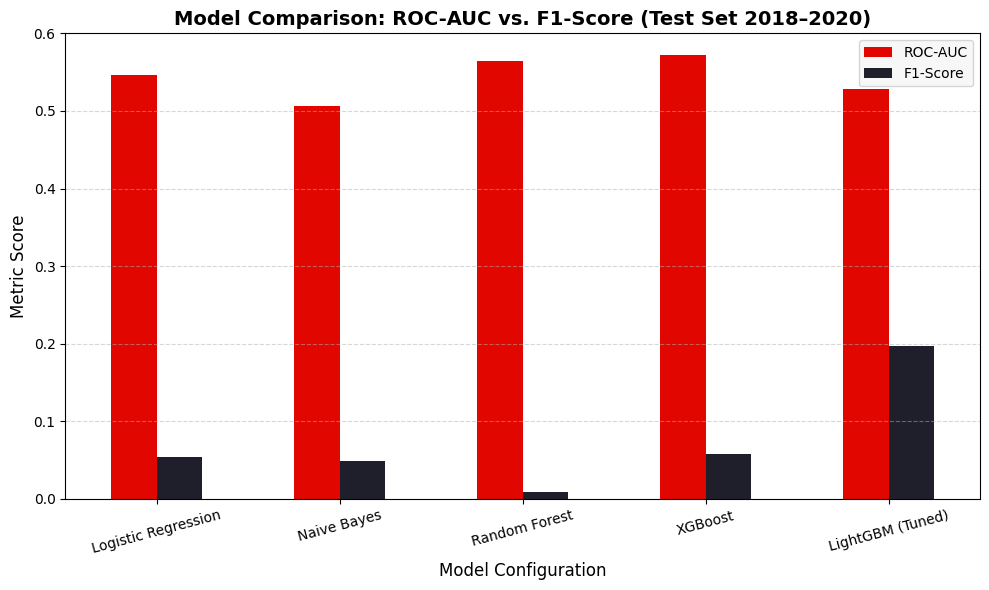

In [15]:
# Compile metrics for table & visualization
metrics = []
for model_name in models_preds.keys():
    y_pred = models_preds[model_name]
    y_prob = models_probs[model_name]
    metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

df_compare = pd.DataFrame(metrics).set_index("Model")
print(df_compare.to_string())

# Chart 1: Bar Chart comparing AUC vs F1-Score
fig, ax = plt.subplots(figsize=(10, 6))
df_compare[["ROC-AUC", "F1-Score"]].plot(kind="bar", ax=ax, color=["#e10600", "#1f1f2b"])
ax.set_title("Model Comparison: ROC-AUC vs. F1-Score (Test Set 2018–2020)", fontsize=14, fontweight="bold")
ax.set_ylabel("Metric Score", fontsize=12)
ax.set_xlabel("Model Configuration", fontsize=12)
ax.set_xticklabels(df_compare.index, rotation=15)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(frameon=True, facecolor="#f5f5f7")
plt.tight_layout()
plt.show()

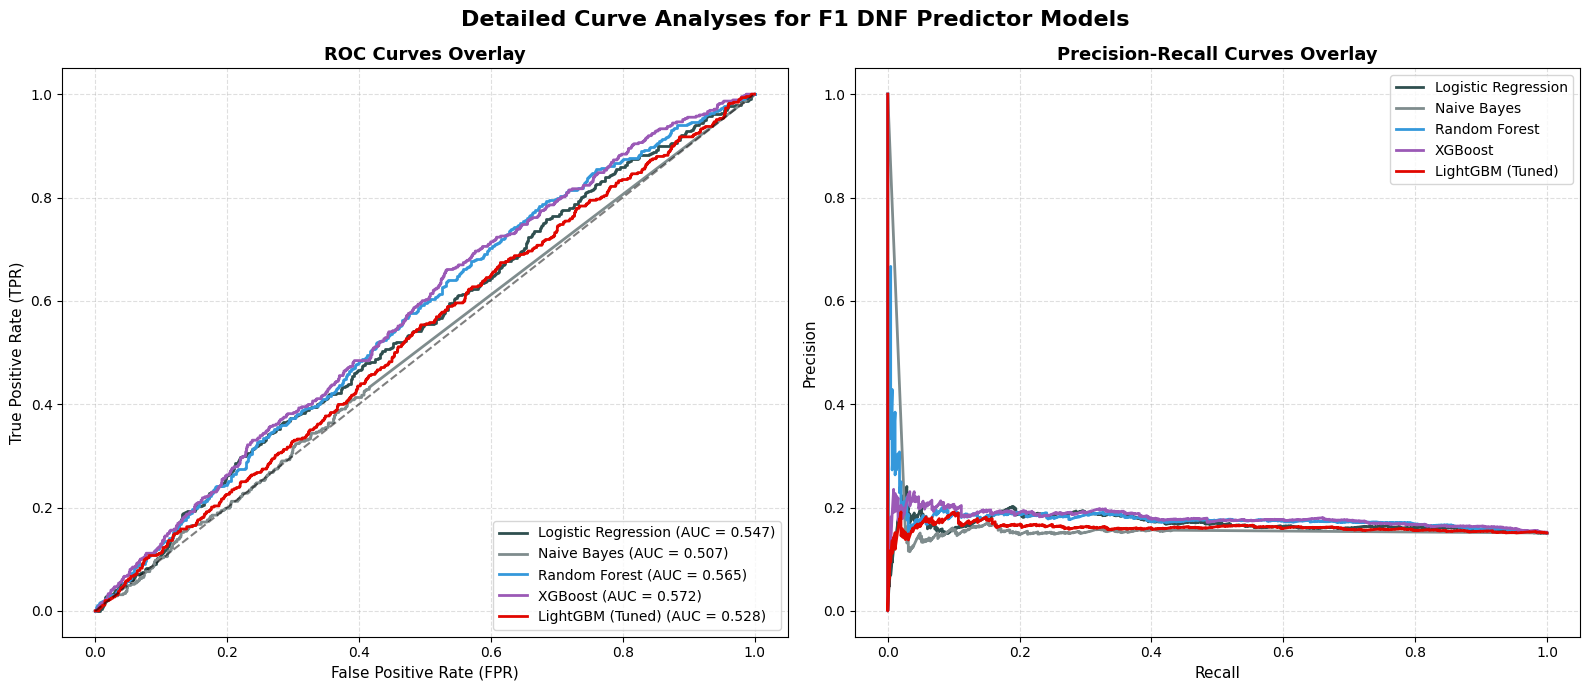

In [16]:
# Chart 2: ROC and Precision-Recall Curves (Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors = {
    "Logistic Regression": "#2f4f4f",
    "Naive Bayes": "#7f8c8d",
    "Random Forest": "#3498db",
    "XGBoost": "#9b59b6",
    "LightGBM (Tuned)": "#e10600"
}

# Left Subplot: ROC Curves
for model_name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})", color=colors[model_name], linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title("ROC Curves Overlay", fontsize=13, fontweight="bold")
ax1.set_xlabel("False Positive Rate (FPR)", fontsize=11)
ax1.set_ylabel("True Positive Rate (TPR)", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(loc="lower right")

# Right Subplot: Precision-Recall Curves (highly relevant for class imbalance)
for model_name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ax2.plot(recall, precision, label=model_name, color=colors[model_name], linewidth=2)
ax2.set_title("Precision-Recall Curves Overlay", fontsize=13, fontweight="bold")
ax2.set_xlabel("Recall", fontsize=11)
ax2.set_ylabel("Precision", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(loc="upper right")

plt.suptitle("Detailed Curve Analyses for F1 DNF Predictor Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Feature Importance & Ablation Study Visualization

We extract LightGBM feature importance to explain feature contribution, and visualize the performance degradation when features are systematically excluded.

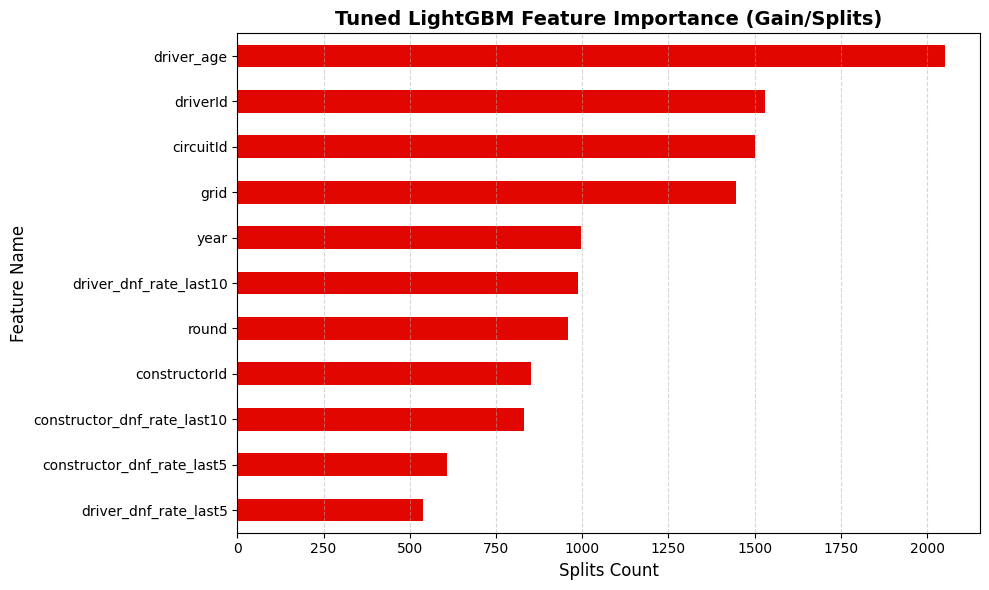

In [17]:
# Chart 3: LightGBM Feature Importance
importance = lgb_tuned.feature_importances_
features = X_train.columns
df_importance = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
df_importance.plot(kind="barh", x="Feature", y="Importance", ax=ax, color="#e10600", legend=False)
ax.set_title("Tuned LightGBM Feature Importance (Gain/Splits)", fontsize=14, fontweight="bold")
ax.set_xlabel("Splits Count", fontsize=12)
ax.set_ylabel("Feature Name", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

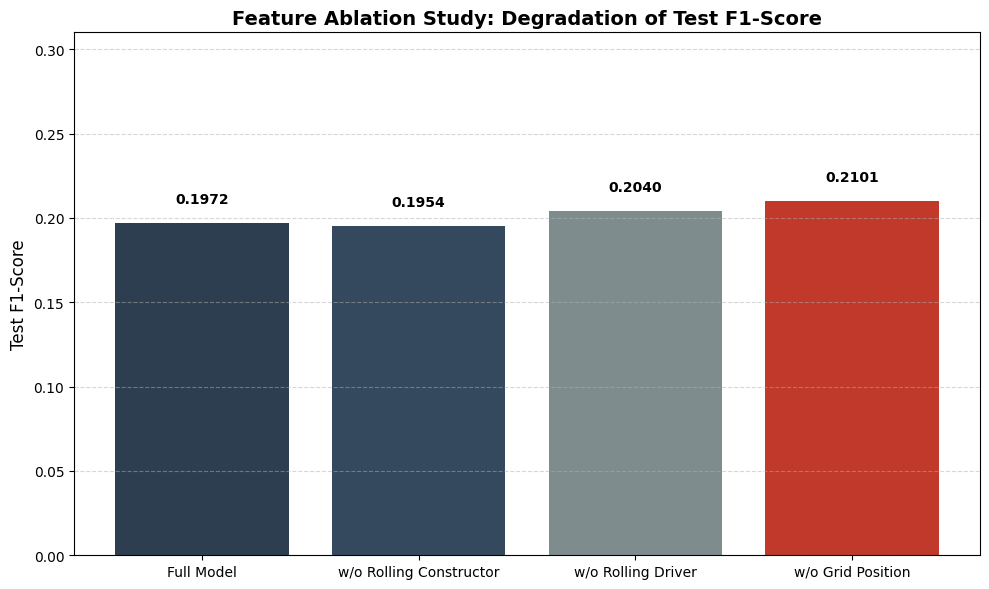

In [18]:
# Chart 4: Ablation Study Performance Drops
# Build the ablation results from our evaluations
ablation_configs = [
    "Full Model",
    "w/o Rolling Constructor",
    "w/o Rolling Driver",
    "w/o Grid Position"
]

# Helper to calculate drops
ablation_f1s = []

# 1. Full
ablation_f1s.append(f1_score(y_test, lgb_tuned.predict(X_test)))

# 2. w/o Constructor reliability
cols_no_const = [c for c in X_train.columns if "constructor_dnf_rate" not in c]
m_no_const = lgb.LGBMClassifier(**params)
m_no_const.fit(X_train[cols_no_const], y_train)
ablation_f1s.append(f1_score(y_test, m_no_const.predict(X_test[cols_no_const])))

# 3. w/o Driver reliability
cols_no_driver = [c for c in X_train.columns if "driver_dnf_rate" not in c]
m_no_driver = lgb.LGBMClassifier(**params)
m_no_driver.fit(X_train[cols_no_driver], y_train)
ablation_f1s.append(f1_score(y_test, m_no_driver.predict(X_test[cols_no_driver])))

# 4. w/o Grid position
cols_no_grid = [c for c in X_train.columns if c != "grid"]
m_no_grid = lgb.LGBMClassifier(**params)
m_no_grid.fit(X_train[cols_no_grid], y_train)
ablation_f1s.append(f1_score(y_test, m_no_grid.predict(X_test[cols_no_grid])))

df_ablation = pd.DataFrame({
    "Configuration": ablation_configs,
    "F1-Score": ablation_f1s
})

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(df_ablation["Configuration"], df_ablation["F1-Score"], color=["#2c3e50", "#34495e", "#7f8c8d", "#c0392b"])
ax.set_title("Feature Ablation Study: Degradation of Test F1-Score", fontsize=14, fontweight="bold")
ax.set_ylabel("Test F1-Score", fontsize=12)
ax.set_ylim(0, max(ablation_f1s) + 0.1)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate F1 scores on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()